# Induction Motor Speed Control Using Reduced-Order Models

This tutorial builds the fifth-order induction motor model used in induction motor speed control. The most commonly used model is one that assumes stator and rotor currents at quasi-steady-state. But other models are also possible. We show how AutoReduce can be used to explore these possible models and to find out what reduced model is most suitable for the given control application. This model is built on the work of Sabir and Ibrir (2018) who used a reduced-order model for induction motor speed control.

> Reference: Sabir, A., and S. Ibrir. "Induction motor speed control using reduced-order model." Automatika: časopis za automatiku, mjerenje, elektroniku, računarstvo i komunikacije 59.3-4 (2018): 274-285.


## The fifth-order motor model

The state vector contains the d-axis and q-axis stator currents, the d-axis and q-axis rotor fluxes, and the rotor mechanical speed:

$$
x =
\begin{bmatrix}
i_{sd} & i_{sq} & \phi_{rd} & \phi_{rq} & \Omega
\end{bmatrix}^{T}.
$$

The model uses the d-axis and q-axis stator voltages and the load torque as prescribed values:

$$
u =
\begin{bmatrix}
v_{sd} & v_{sq} & T_L
\end{bmatrix}^{T}.
$$

The fifth-order nonlinear equations are

$$
\begin{aligned}
\dot{i}_{sd} &= -\gamma i_{sd}+\omega_s i_{sq}+ba\phi_{rd}+bp\Omega\phi_{rq}+m_1v_{sd}, \\
\dot{i}_{sq} &= -\omega_s i_{sd}-\gamma i_{sq}-bp\Omega\phi_{rd}+ba\phi_{rq}+m_1v_{sq}, \\
\dot{\phi}_{rd} &= aM_{sr}i_{sd}-a\phi_{rd}+(\omega_s-p\Omega)\phi_{rq}, \\
\dot{\phi}_{rq} &= aM_{sr}i_{sq}-(\omega_s-p\Omega)\phi_{rd}-a\phi_{rq}, \\
\dot{\Omega} &= m(\phi_{rd}i_{sq}-\phi_{rq}i_{sd})-c\Omega-\frac{T_L}{J}.
\end{aligned}
$$

The output for model reduction is the rotor speed, $y=\Omega$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display, Math
from sympy import latex

from autoreduce import System, load_ode_model, solve_ode, solve_timescale_separation


## Set the motor parameters

The numerical values below come from the induction motor example. The line-to-line RMS voltage is converted into the phase-peak d-axis voltage used by the dq model.


In [2]:
line_voltage_rms = 460.0
phase_peak_voltage = np.sqrt(2.0) * line_voltage_rms / np.sqrt(3.0)

motor_params_values = np.array([
    0.087,               # Rs: stator resistance, ohms
    0.228,               # Rr: rotor resistance, ohms
    0.0355,              # Ls: stator inductance, H
    0.0355,              # Lr: rotor inductance, H
    0.0347,              # Msr: mutual inductance, H
    1.662,               # J: rotor inertia, kg m^2
    0.1,                 # fv: viscous friction coefficient
    2.0,                 # p: pole pairs
    377.0,               # omega_s: synchronous electrical speed, rad/s
    phase_peak_voltage,  # vsd: d-axis stator voltage
    0.0,                 # vsq: q-axis stator voltage
    0.0,                 # Tl: load torque, N m
])

motor_parameter_names = [
    "Rs", "Rr", "Ls", "Lr", "Msr", "J", "fv", "p", "omega_s", "vsd", "vsq", "Tl"
]

motor_parameter_values = dict(zip(motor_parameter_names, motor_params_values))
motor_parameter_values

{'Rs': np.float64(0.087),
 'Rr': np.float64(0.228),
 'Ls': np.float64(0.0355),
 'Lr': np.float64(0.0355),
 'Msr': np.float64(0.0347),
 'J': np.float64(1.662),
 'fv': np.float64(0.1),
 'p': np.float64(2.0),
 'omega_s': np.float64(377.0),
 'vsd': np.float64(375.588427226754),
 'vsq': np.float64(0.0),
 'Tl': np.float64(0.0)}

## Build the AutoReduce system

This cell maps the physical motor variables into AutoReduce's symbolic state and parameter containers. The auxiliary constants $a$, $b$, $c$, $\gamma$, $m$, and $m_1$ remain symbolic expressions of the motor parameters.


In [3]:
motor_states, motor_rhs, motor_params = load_ode_model(5, len(motor_params_values))
Rs, Rr, Ls, Lr, Msr, J, fv, p, omega_s, vsd, vsq, Tl = motor_params
i_sd, i_sq, phi_rd, phi_rq, Omega = motor_states

sigma = 1 - Msr**2 / (Ls * Lr)
a = Rr / Lr
b = Msr / (sigma * Ls * Lr)
c = fv / J
gamma = (Lr**2 * Rs + Msr**2 * Rr) / (sigma * Ls * Lr**2)
m = p * Msr / (J * Lr)
m1 = 1 / (sigma * Ls)
slip = omega_s - p * Omega

motor_rhs[0] = -gamma * i_sd + omega_s * i_sq + b * a * phi_rd + b * p * Omega * phi_rq + m1 * vsd
motor_rhs[1] = -omega_s * i_sd - gamma * i_sq - b * p * Omega * phi_rd + b * a * phi_rq + m1 * vsq
motor_rhs[2] = a * Msr * i_sd - a * phi_rd + slip * phi_rq
motor_rhs[3] = a * Msr * i_sq - slip * phi_rd - a * phi_rq
motor_rhs[4] = m * (phi_rd * i_sq - phi_rq * i_sd) - c * Omega - Tl / J

motor_x_init = np.zeros(len(motor_states))
motor_C = np.zeros((1, len(motor_states)), dtype=int)
motor_C[0, 4] = 1
motor_params_dict = dict(zip(motor_params, motor_params_values))

motor_system = System(
    motor_states,
    motor_rhs,
    params_dict=motor_params_dict,
    C=motor_C.tolist(),
    x_init=motor_x_init,
)

In [4]:
display(Math(r"\dot{x} = " + latex(motor_rhs)))

for state, label in zip(
    motor_states,
    ["d-axis stator current", "q-axis stator current", "d-axis rotor flux", "q-axis rotor flux", "rotor mechanical speed"],
):
    print(f"{state}: {label}")


<IPython.core.display.Math object>

x0: d-axis stator current
x1: q-axis stator current
x2: d-axis rotor flux
x3: q-axis rotor flux
x4: rotor mechanical speed


## Simulate the full-order model

The first simulation uses no applied load torque, so the motor accelerates from rest under the nominal voltage. This full fifth-order solution is the reference trajectory for the first reduction comparison.


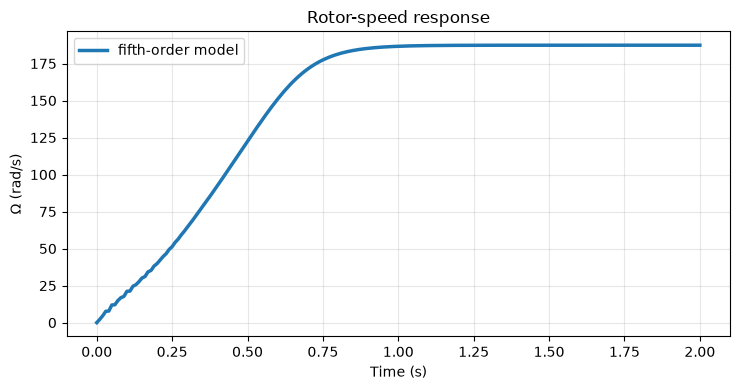

In [5]:
timepoints = np.linspace(0.0, 2.0, 201)
full_solution = solve_ode(motor_system, timepoints).T
rotor_speed = full_solution[4]

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(timepoints, rotor_speed, linewidth=2.5, label="fifth-order model")
ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$\Omega$ (rad/s)")
ax.set_title("Rotor-speed response")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


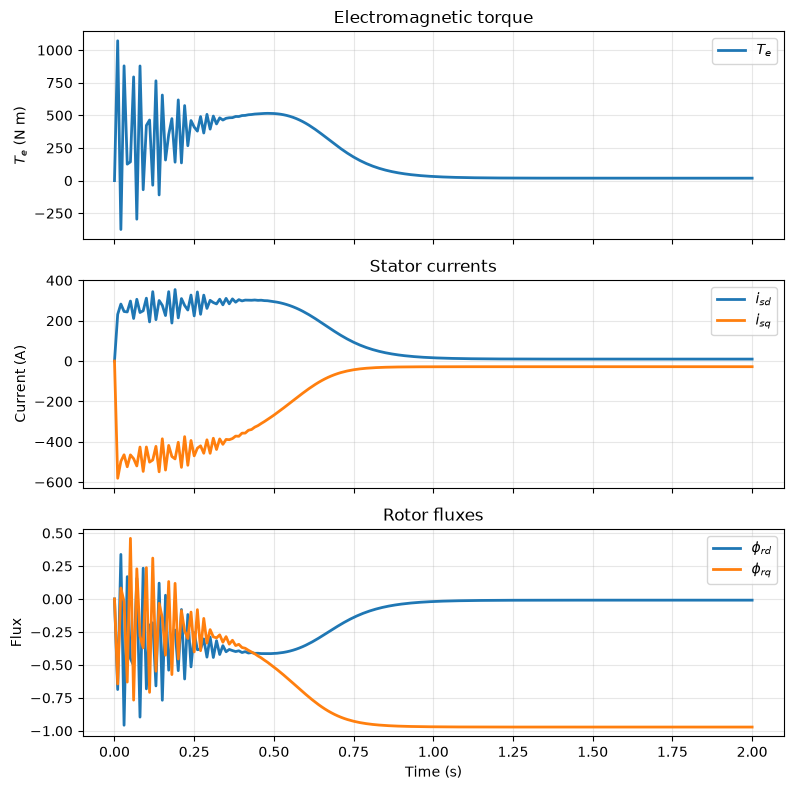

In [6]:
torque_gain = motor_system.params_dict[p] * motor_system.params_dict[Msr] / motor_system.params_dict[Lr]
electromagnetic_torque = torque_gain * (
    full_solution[2] * full_solution[1]
    - full_solution[3] * full_solution[0]
)

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(timepoints, electromagnetic_torque, linewidth=2, label=r"$T_e$")
axes[0].set_ylabel(r"$T_e$ (N m)")
axes[0].set_title("Electromagnetic torque")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(timepoints, full_solution[0], linewidth=2, label=r"$i_{sd}$")
axes[1].plot(timepoints, full_solution[1], linewidth=2, label=r"$i_{sq}$")
axes[1].set_ylabel("Current (A)")
axes[1].set_title("Stator currents")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(timepoints, full_solution[2], linewidth=2, label=r"$\phi_{rd}$")
axes[2].plot(timepoints, full_solution[3], linewidth=2, label=r"$\phi_{rq}$")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Flux")
axes[2].set_title("Rotor fluxes")
axes[2].grid(alpha=0.3)
axes[2].legend()

fig.tight_layout()
plt.show()

## Choose reduced-order models

Using AutoReduce, we explore various quasi-steady-state reductions by explicitly listing the states that remain dynamic. One candidate keeps only a stator current and speed. One candidate keeps the two rotor fluxes and speed, matching the third-order state choice discussed in the reference paper. The other candidates retain nearby current-flux-speed combinations.


In [7]:
reduction_timepoints_ssm = np.linspace(0.05, 2.0, 5)

reduced_current_speed, _ = solve_timescale_separation(
    motor_system,
    [i_sd, Omega],
    timepoints_ode=timepoints,
    timepoints_ssm=reduction_timepoints_ssm,
)

reduced_paper_flux_speed, _ = solve_timescale_separation(
    motor_system,
    [phi_rd, phi_rq, Omega],
    timepoints_ode=timepoints,
    timepoints_ssm=reduction_timepoints_ssm,
)

reduced_current_flux_speed, _ = solve_timescale_separation(
    motor_system,
    [i_sd, phi_rq, Omega],
    timepoints_ode=timepoints,
    timepoints_ssm=reduction_timepoints_ssm,
)

reduced_four_state, _ = solve_timescale_separation(
    motor_system,
    [i_sd, phi_rd, phi_rq, Omega],
    timepoints_ode=timepoints,
    timepoints_ssm=reduction_timepoints_ssm,
)

motor_reduced_models = [
    ("current-speed: i_sd, Omega", reduced_current_speed),
    ("paper flux-speed: phi_rd, phi_rq, Omega", reduced_paper_flux_speed),
    ("current-flux-speed: i_sd, phi_rq, Omega", reduced_current_flux_speed),
    ("four-state: i_sd, phi_rd, phi_rq, Omega", reduced_four_state),
]

for _, reduced_model in motor_reduced_models:
    reduced_model.C = [[1 if state == Omega else 0 for state in reduced_model.x]]


Successful solution obtained with states: [x0, x4]!
Successful solution obtained with states: [x2, x3, x4]!
Successful solution obtained with states: [x0, x3, x4]!
Successful solution obtained with states: [x0, x2, x3, x4]!


In [8]:
for model_name, reduced_model in motor_reduced_models:
    print(model_name)
    print("retained states:", reduced_model.x)
    display(Math(r"\text{reduced equations: } " + latex(reduced_model.f)))
    print()


current-speed: i_sd, Omega
retained states: [x0, x4]


<IPython.core.display.Math object>


paper flux-speed: phi_rd, phi_rq, Omega
retained states: [x2, x3, x4]


<IPython.core.display.Math object>


current-flux-speed: i_sd, phi_rq, Omega
retained states: [x0, x3, x4]


<IPython.core.display.Math object>


four-state: i_sd, phi_rd, phi_rq, Omega
retained states: [x0, x2, x3, x4]


<IPython.core.display.Math object>

## Compare rotor-speed outputs

The comparison uses rotor speed because that is the selected output, $y=\Omega$. The errors are small near the final speed, but the mean absolute error still shows which state choices follow the full transient more closely.


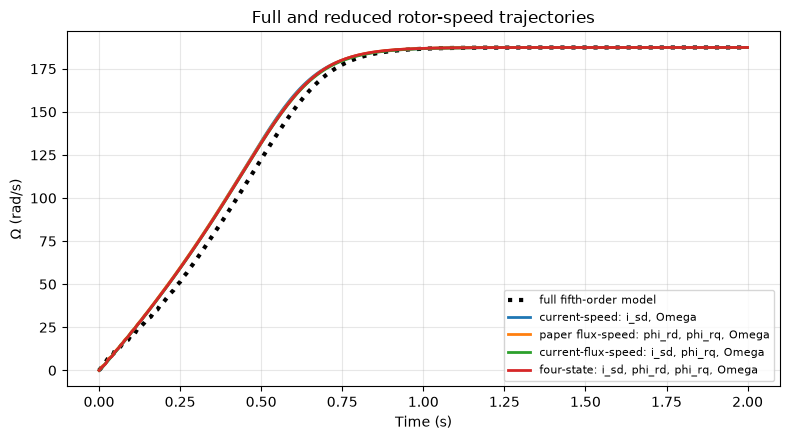

[{'model': 'current-speed: i_sd, Omega',
  'MAE': 2.603328658858775,
  'RMSE': 4.55861453273446,
  'final speed error': 1.332148315213999e-05},
 {'model': 'paper flux-speed: phi_rd, phi_rq, Omega',
  'MAE': 2.583378656655576,
  'RMSE': 4.475722796613856,
  'final speed error': 3.6656476822827244e-06},
 {'model': 'current-flux-speed: i_sd, phi_rq, Omega',
  'MAE': 2.3547724655388906,
  'RMSE': 4.15137199393485,
  'final speed error': 1.538109307830382e-05},
 {'model': 'four-state: i_sd, phi_rd, phi_rq, Omega',
  'MAE': 2.4685029770172715,
  'RMSE': 4.267054728331146,
  'final speed error': 4.355007803269473e-06}]

In [9]:
full_speed = full_solution[4]
motor_reduction_summary = []

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    timepoints,
    full_speed,
    linestyle=":",
    linewidth=3,
    color="black",
    label="full fifth-order model",
)

for model_name, reduced_model in motor_reduced_models:
    reduced_solution = solve_ode(reduced_model, timepoints).T
    reduced_speed = np.ravel(np.asarray(reduced_model.C, dtype=float) @ reduced_solution)
    speed_error = full_speed - reduced_speed

    motor_reduction_summary.append({
        "model": model_name,
        "MAE": float(np.mean(np.abs(speed_error))),
        "RMSE": float(np.sqrt(np.mean(speed_error**2))),
        "final speed error": float(abs(full_speed[-1] - reduced_speed[-1])),
    })

    ax.plot(
        timepoints,
        reduced_speed,
        linewidth=2,
        label=model_name,
    )

ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$\Omega$ (rad/s)")
ax.set_title("Full and reduced rotor-speed trajectories")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

motor_reduction_summary


## Change operating conditions

A reduced model that works for one operating point may not be the best choice after the load, supply voltage, or rotor resistance changes. The following cells keep the same reduced-state choices and evaluate them under four constant conditions: no load, a larger load torque, a voltage sag, and increased rotor resistance.


In [10]:
import pandas as pd

default_motor_params_dict = motor_system.params_dict.copy()

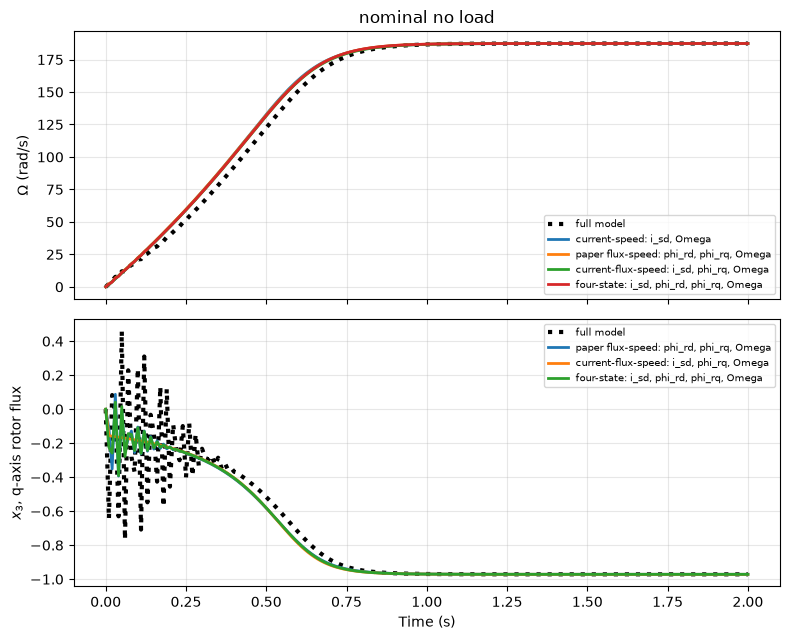

,model,speed MAE,final speed error,x3 MAE,final x3 error
0,"current-speed: i_sd, Omega",2.603329,0.000013,NaN,NaN
1,"paper flux-speed: phi_rd, phi_rq, Omega",2.583379,0.000004,0.047298,4.391621e-09
2,"current-flux-speed: i_sd, phi_rq, Omega",2.354772,0.000015,0.050138,2.235849e-08
3,"four-state: i_sd, phi_rd, phi_rq, Omega",2.468503,0.000004,0.045536,1.116816e-08


In [11]:
condition_name = "nominal no load"
condition_params_dict = default_motor_params_dict.copy()
motor_system.set_param_dict(condition_params_dict)

condition_solution = solve_ode(motor_system, timepoints).T
condition_speed = condition_solution[4]
condition_x3 = condition_solution[3]

nominal_no_load_summary = []
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True)

axes[0].plot(
    timepoints,
    condition_speed,
    linestyle=":",
    linewidth=3,
    color="black",
    label="full model",
)
axes[1].plot(
    timepoints,
    condition_x3,
    linestyle=":",
    linewidth=3,
    color="black",
    label="full model",
)

for model_name, reduced_model in motor_reduced_models:
    reduced_model.set_param_dict(condition_params_dict)
    reduced_solution = solve_ode(reduced_model, timepoints).T
    reduced_speed = np.ravel(np.asarray(reduced_model.C, dtype=float) @ reduced_solution)
    speed_error = condition_speed - reduced_speed

    summary_row = {
        "model": model_name,
        "speed MAE": float(np.mean(np.abs(speed_error))),
        "final speed error": float(abs(condition_speed[-1] - reduced_speed[-1])),
        "x3 MAE": np.nan,
        "final x3 error": np.nan,
    }

    axes[0].plot(timepoints, reduced_speed, linewidth=2, label=model_name)

    if phi_rq in reduced_model.x:
        reduced_x3 = reduced_solution[reduced_model.x.index(phi_rq)]
        x3_error = condition_x3 - reduced_x3
        summary_row["x3 MAE"] = float(np.mean(np.abs(x3_error)))
        summary_row["final x3 error"] = float(abs(condition_x3[-1] - reduced_x3[-1]))
        axes[1].plot(timepoints, reduced_x3, linewidth=2, label=model_name)

    nominal_no_load_summary.append(summary_row)

axes[0].set_title(condition_name)
axes[0].set_ylabel(r"$\Omega$ (rad/s)")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=7)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel(r"$x_3$, q-axis rotor flux")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=7)
fig.tight_layout()
plt.show()

display(pd.DataFrame(nominal_no_load_summary))

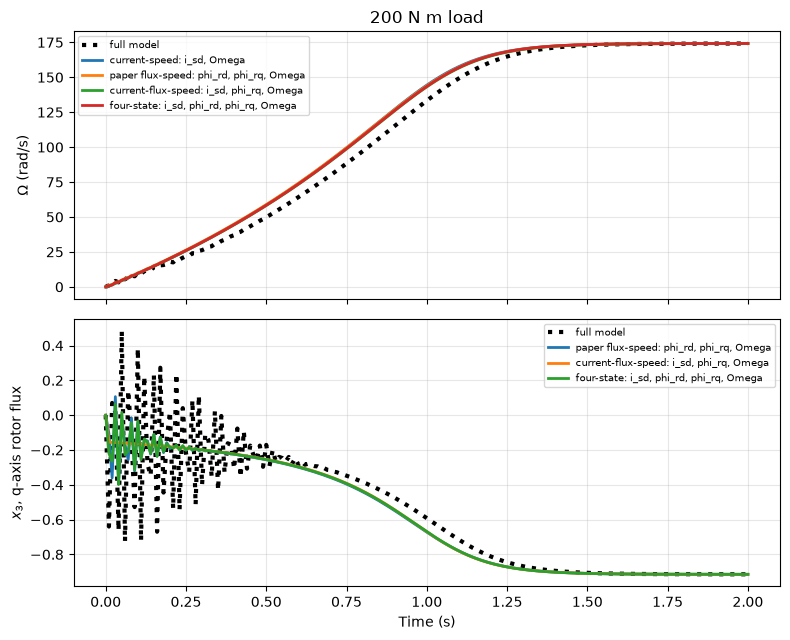

,model,speed MAE,final speed error,x3 MAE,final x3 error
0,"current-speed: i_sd, Omega",4.928197,0.005382,NaN,NaN
1,"paper flux-speed: phi_rd, phi_rq, Omega",4.921355,0.007007,0.075841,0.000044
2,"current-flux-speed: i_sd, phi_rq, Omega",4.525878,0.003453,0.078266,0.000030
3,"four-state: i_sd, phi_rd, phi_rq, Omega",4.663898,0.007606,0.072597,0.000051


In [12]:
condition_name = "200 N m load"
condition_params_dict = default_motor_params_dict.copy()
condition_params_dict[Tl] = 200.0
motor_system.set_param_dict(condition_params_dict)

condition_solution = solve_ode(motor_system, timepoints).T
condition_speed = condition_solution[4]
condition_x3 = condition_solution[3]

load_summary = []
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True)

axes[0].plot(
    timepoints,
    condition_speed,
    linestyle=":",
    linewidth=3,
    color="black",
    label="full model",
)
axes[1].plot(
    timepoints,
    condition_x3,
    linestyle=":",
    linewidth=3,
    color="black",
    label="full model",
)

for model_name, reduced_model in motor_reduced_models:
    reduced_model.set_param_dict(condition_params_dict)
    reduced_solution = solve_ode(reduced_model, timepoints).T
    reduced_speed = np.ravel(np.asarray(reduced_model.C, dtype=float) @ reduced_solution)
    speed_error = condition_speed - reduced_speed

    summary_row = {
        "model": model_name,
        "speed MAE": float(np.mean(np.abs(speed_error))),
        "final speed error": float(abs(condition_speed[-1] - reduced_speed[-1])),
        "x3 MAE": np.nan,
        "final x3 error": np.nan,
    }

    axes[0].plot(timepoints, reduced_speed, linewidth=2, label=model_name)

    if phi_rq in reduced_model.x:
        reduced_x3 = reduced_solution[reduced_model.x.index(phi_rq)]
        x3_error = condition_x3 - reduced_x3
        summary_row["x3 MAE"] = float(np.mean(np.abs(x3_error)))
        summary_row["final x3 error"] = float(abs(condition_x3[-1] - reduced_x3[-1]))
        axes[1].plot(timepoints, reduced_x3, linewidth=2, label=model_name)

    load_summary.append(summary_row)

axes[0].set_title(condition_name)
axes[0].set_ylabel(r"$\Omega$ (rad/s)")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=7)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel(r"$x_3$, q-axis rotor flux")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=7)
fig.tight_layout()
plt.show()

display(pd.DataFrame(load_summary))

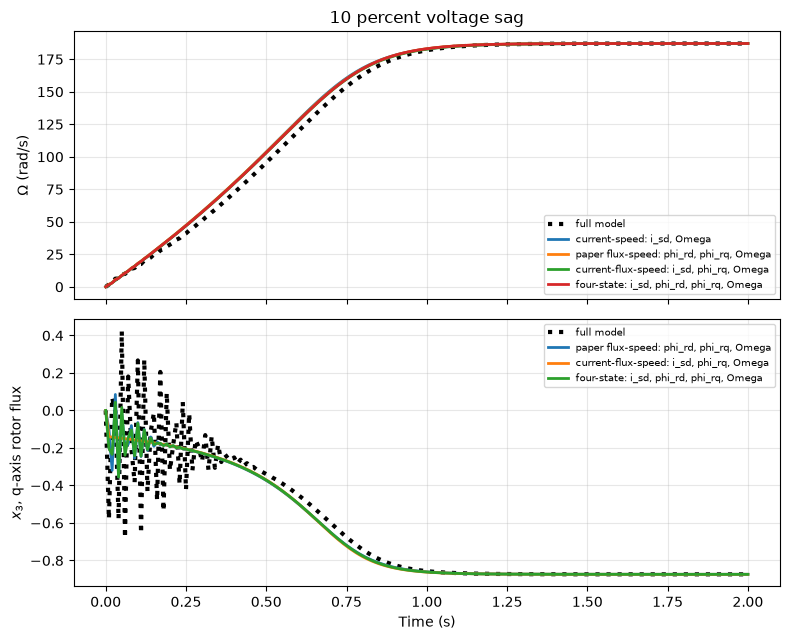

,model,speed MAE,final speed error,x3 MAE,final x3 error
0,"current-speed: i_sd, Omega",2.674239,0.000282,NaN,NaN
1,"paper flux-speed: phi_rd, phi_rq, Omega",2.655566,0.000230,0.046822,3.023468e-07
2,"current-flux-speed: i_sd, phi_rq, Omega",2.424568,0.000358,0.049682,2.879184e-07
3,"four-state: i_sd, phi_rd, phi_rq, Omega",2.539847,0.000244,0.045089,5.677020e-07


In [13]:
condition_name = "10 percent voltage sag"
condition_params_dict = default_motor_params_dict.copy()
condition_params_dict[vsd] = np.sqrt(2.0) * (0.90 * line_voltage_rms) / np.sqrt(3.0)
motor_system.set_param_dict(condition_params_dict)

condition_solution = solve_ode(motor_system, timepoints).T
condition_speed = condition_solution[4]
condition_x3 = condition_solution[3]

voltage_sag_summary = []
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True)

axes[0].plot(
    timepoints,
    condition_speed,
    linestyle=":",
    linewidth=3,
    color="black",
    label="full model",
)
axes[1].plot(
    timepoints,
    condition_x3,
    linestyle=":",
    linewidth=3,
    color="black",
    label="full model",
)

for model_name, reduced_model in motor_reduced_models:
    reduced_model.set_param_dict(condition_params_dict)
    reduced_solution = solve_ode(reduced_model, timepoints).T
    reduced_speed = np.ravel(np.asarray(reduced_model.C, dtype=float) @ reduced_solution)
    speed_error = condition_speed - reduced_speed

    summary_row = {
        "model": model_name,
        "speed MAE": float(np.mean(np.abs(speed_error))),
        "final speed error": float(abs(condition_speed[-1] - reduced_speed[-1])),
        "x3 MAE": np.nan,
        "final x3 error": np.nan,
    }

    axes[0].plot(timepoints, reduced_speed, linewidth=2, label=model_name)

    if phi_rq in reduced_model.x:
        reduced_x3 = reduced_solution[reduced_model.x.index(phi_rq)]
        x3_error = condition_x3 - reduced_x3
        summary_row["x3 MAE"] = float(np.mean(np.abs(x3_error)))
        summary_row["final x3 error"] = float(abs(condition_x3[-1] - reduced_x3[-1]))
        axes[1].plot(timepoints, reduced_x3, linewidth=2, label=model_name)

    voltage_sag_summary.append(summary_row)

axes[0].set_title(condition_name)
axes[0].set_ylabel(r"$\Omega$ (rad/s)")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=7)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel(r"$x_3$, q-axis rotor flux")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=7)
fig.tight_layout()
plt.show()

display(pd.DataFrame(voltage_sag_summary))

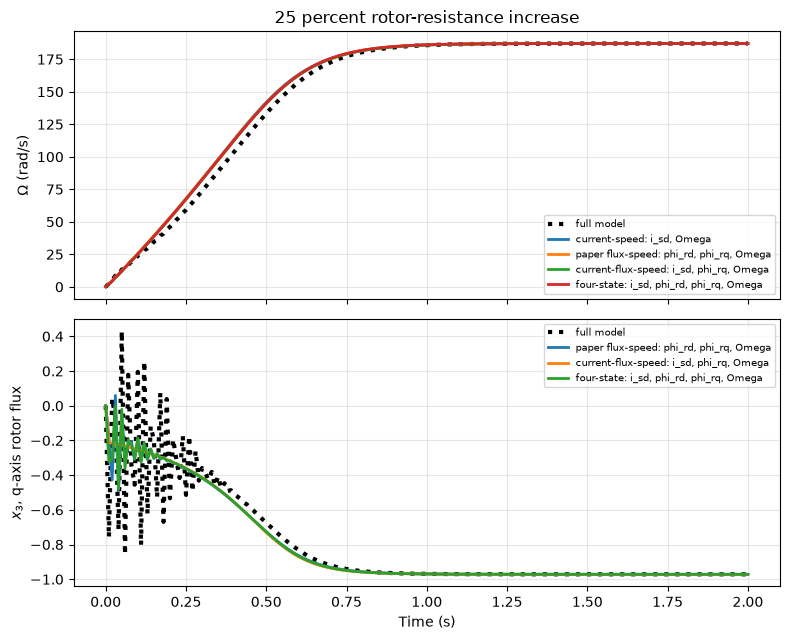

,model,speed MAE,final speed error,x3 MAE,final x3 error
0,"current-speed: i_sd, Omega",2.373599,0.000073,NaN,NaN
1,"paper flux-speed: phi_rd, phi_rq, Omega",2.357764,0.000060,0.046499,5.696386e-08
2,"current-flux-speed: i_sd, phi_rq, Omega",2.154408,0.000089,0.049757,5.200329e-08
3,"four-state: i_sd, phi_rd, phi_rq, Omega",2.253376,0.000064,0.044416,1.235121e-07


In [14]:
condition_name = "25 percent rotor-resistance increase"
condition_params_dict = default_motor_params_dict.copy()
condition_params_dict[Rr] = 1.25 * default_motor_params_dict[Rr]
motor_system.set_param_dict(condition_params_dict)

condition_solution = solve_ode(motor_system, timepoints).T
condition_speed = condition_solution[4]
condition_x3 = condition_solution[3]

rotor_resistance_summary = []
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True)

axes[0].plot(
    timepoints,
    condition_speed,
    linestyle=":",
    linewidth=3,
    color="black",
    label="full model",
)
axes[1].plot(
    timepoints,
    condition_x3,
    linestyle=":",
    linewidth=3,
    color="black",
    label="full model",
)

for model_name, reduced_model in motor_reduced_models:
    reduced_model.set_param_dict(condition_params_dict)
    reduced_solution = solve_ode(reduced_model, timepoints).T
    reduced_speed = np.ravel(np.asarray(reduced_model.C, dtype=float) @ reduced_solution)
    speed_error = condition_speed - reduced_speed

    summary_row = {
        "model": model_name,
        "speed MAE": float(np.mean(np.abs(speed_error))),
        "final speed error": float(abs(condition_speed[-1] - reduced_speed[-1])),
        "x3 MAE": np.nan,
        "final x3 error": np.nan,
    }

    axes[0].plot(timepoints, reduced_speed, linewidth=2, label=model_name)

    if phi_rq in reduced_model.x:
        reduced_x3 = reduced_solution[reduced_model.x.index(phi_rq)]
        x3_error = condition_x3 - reduced_x3
        summary_row["x3 MAE"] = float(np.mean(np.abs(x3_error)))
        summary_row["final x3 error"] = float(abs(condition_x3[-1] - reduced_x3[-1]))
        axes[1].plot(timepoints, reduced_x3, linewidth=2, label=model_name)

    rotor_resistance_summary.append(summary_row)

axes[0].set_title(condition_name)
axes[0].set_ylabel(r"$\Omega$ (rad/s)")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=7)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel(r"$x_3$, q-axis rotor flux")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=7)
fig.tight_layout()
plt.show()

display(pd.DataFrame(rotor_resistance_summary))

## Conclusion
The reduced models do not all respond to changed operating conditions in the same way. The current-flux-speed model is usually closest for rotor speed in this setup, while the paper's flux-speed model gives a compact third-order alternative with a direct physical interpretation. The ranking changes only modestly across the tested load, voltage, and rotor-resistance regimes, which suggests that the retained electromechanical coupling is more important than simply keeping the largest number of states.
